In [44]:
import pandas as pd
import numpy as np
df1=pd.read_csv("ohio_training_combined.csv")
df1['timestamp'] = pd.to_datetime(df1['timestamp'], format='%d-%m-%Y %H:%M:%S')
df1=df1.sort_values(['patient_id', 'timestamp'])

In [45]:
g = df1.groupby('patient_id')['glucose']

In [46]:
df1['lag_1']  = g.shift(1)
df1['lag_2']  = g.shift(2)
df1['lag_3']  = g.shift(3)
df1['lag_6']  = g.shift(6)
df1['lag_12'] = g.shift(12)

In [47]:
df1['roll_mean_30'] = g.transform(lambda x: x.rolling(6).mean())
df1['roll_std_30']  = g.transform(lambda x: x.rolling(6).std())
df1['roll_mean_60'] = g.transform(lambda x: x.rolling(12).mean())
df1['roll_std_60']  = g.transform(lambda x: x.rolling(12).std())
df1['roll_mean_90'] = g.transform(lambda x: x.rolling(18).mean())
df1['roll_std_90']  = g.transform(lambda x: x.rolling(18).std())
df1['roll_mean_120'] = g.transform(lambda x: x.rolling(24).mean())
df1['roll_std_120']  = g.transform(lambda x: x.rolling(24).std())

In [48]:
df1['delta_5']  = df1['glucose'] - df1['lag_1']
df1['delta_30'] = df1['glucose'] - df1['lag_6']

In [49]:
df1['hour'] = df1['timestamp'].dt.hour + df1['timestamp'].dt.minute / 60
df1['hour_sin'] = np.sin(2*np.pi*df1['hour']/24)
df1['hour_cos'] = np.cos(2*np.pi*df1['hour']/24)

In [50]:
df1['target_30'] = g.shift(-6)
df1['target_60'] = g.shift(-12)
df1['target_90'] = g.shift(-18)
df1['target_120'] = g.shift(-24)

In [51]:
df1=df1.dropna()

In [52]:
X_train=df1.drop(columns=['glucose','patient_id','timestamp','target_30','target_60','target_90','target_120'])
Y1_train=df1['target_30']
Y2_train=df1['target_60']
Y3_train=df1['target_90']
Y4_train=df1['target_120']

In [53]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
model1=XGBRegressor()
model2=XGBRegressor()
model3=XGBRegressor()
model4=XGBRegressor()

In [54]:
model1.fit(X_train, Y1_train)
model2.fit(X_train, Y2_train)
model3.fit(X_train, Y3_train)
model4.fit(X_train, Y4_train)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XG

In [55]:
df2=pd.read_csv("ohio_testing_combined.csv")
df2['timestamp'] = pd.to_datetime(df2['timestamp'], format='%d-%m-%Y %H:%M:%S')
df2=df2.sort_values(['patient_id', 'timestamp'])

In [56]:
f = df2.groupby('patient_id')['glucose']

In [57]:
df2['lag_1']  = f.shift(1)
df2['lag_2']  = f.shift(2)
df2['lag_3']  = f.shift(3)
df2['lag_6']  = f.shift(6)
df2['lag_12'] = f.shift(12)

In [58]:
df2['roll_mean_30'] = f.transform(lambda x: x.rolling(6).mean())
df2['roll_std_30']  = f.transform(lambda x: x.rolling(6).std())
df2['roll_mean_60'] = f.transform(lambda x: x.rolling(12).mean())
df2['roll_std_60']  = f.transform(lambda x: x.rolling(12).std())
df2['roll_mean_90'] = f.transform(lambda x: x.rolling(18).mean())
df2['roll_std_90']  = f.transform(lambda x: x.rolling(18).std())
df2['roll_mean_120'] = f.transform(lambda x: x.rolling(24).mean())
df2['roll_std_120']  = f.transform(lambda x: x.rolling(24).std())

In [59]:
df2['delta_5']  = df2['glucose'] - df2['lag_1']
df2['delta_30'] = df2['glucose'] - df2['lag_6']

In [60]:
df2['hour'] = df2['timestamp'].dt.hour + df2['timestamp'].dt.minute / 60
df2['hour_sin'] = np.sin(2*np.pi*df2['hour']/24)
df2['hour_cos'] = np.cos(2*np.pi*df2['hour']/24)

In [61]:
df2['target_30'] = f.shift(-6)
df2['target_60'] = f.shift(-12)
df2['target_90'] = f.shift(-18)
df2['target_120'] = f.shift(-24)
df2=df2.dropna()
X_test=df2.drop(columns=['glucose','patient_id','timestamp','target_30','target_60','target_90','target_120'])
Y1_test=df2['target_30']
Y2_test=df2['target_60']
Y3_test=df2['target_90']
Y4_test=df2['target_120']

In [62]:
Y1_pred=model1.predict(X_test)
Y2_pred=model2.predict(X_test)
Y3_pred=model3.predict(X_test)
Y4_pred=model4.predict(X_test)

In [63]:
print(np.sqrt(mean_squared_error(Y1_test, Y1_pred)))
print(np.sqrt(mean_squared_error(Y2_test, Y2_pred)))
print(np.sqrt(mean_squared_error(Y3_test, Y3_pred)))
print(np.sqrt(mean_squared_error(Y4_test, Y4_pred)))

20.935559340580614
33.66838523967799
42.43867052195493
48.08300853458637


In [64]:
import matplotlib.pyplot as plt
def clarke_error_grid(ref_values, pred_values):
    ref_values = np.array(ref_values)
    pred_values = np.array(pred_values)

    assert len(ref_values) == len(pred_values), "Mismatched lengths"

    zone = [0] * 5  # A, B, C, D, E
    zone_labels = []

    for i in range(len(ref_values)):
        ref = ref_values[i]
        pred = pred_values[i]

        if (ref <= 70 and pred <= 70) or (pred <= 1.2*ref and pred >= 0.8*ref):
            zone[0] += 1; zone_labels.append('A')
        elif (ref >= 180 and pred <= 70) or (ref <= 70 and pred >= 180):
            zone[4] += 1; zone_labels.append('E')
        elif ((ref >= 70 and ref <= 290) and pred >= ref + 110) or \
             ((ref >= 130 and ref <= 180) and (pred <= (7/5)*ref - 182)):
            zone[2] += 1; zone_labels.append('C')
        elif (ref >= 240 and (pred >= 70 and pred <= 180)) or \
             (ref <= 175/3 and pred <= 180 and pred >= 70) or \
             ((ref >= 175/3 and ref <= 70) and pred >= (6/5)*ref):
            zone[3] += 1; zone_labels.append('D')
        else:
            zone[1] += 1; zone_labels.append('B')

    return np.array(zone_labels), zone

In [65]:
def plot_clarke_grid(y_true, y_pred, title="Clarke Error Grid"):
    zones, counts = clarke_error_grid(y_true, y_pred)
    colors = {'A':'green','B':'yellow','C':'orange','D':'red','E':'darkred'}

    plt.figure(figsize=(7,7))
    for z in ['A','B','C','D','E']:
        mask = zones == z
        plt.scatter(np.array(y_true)[mask], np.array(y_pred)[mask],
                    c=colors[z], label=f'Zone {z} ({mask.sum()})', s=10, alpha=0.6)

    plt.plot([0,400],[0,400],'k--',linewidth=0.8)
    plt.xlim(0,400); plt.ylim(0,400)
    plt.xlabel('Reference glucose (mg/dL)')
    plt.ylabel('Predicted glucose (mg/dL)')
    plt.title(title)
    plt.legend()
    plt.show()

    total = len(zones)
    pct = {z: c/total*100 for z, c in zip(['A','B','C','D','E'], counts)}
    print("Zone breakdown (%):")
    for z in ['A','B','C','D','E']:
        print(f"  {z}: {pct[z]:.2f}%")
    print(f"\nClinically safe (A+B): {pct['A']+pct['B']:.2f}%")
    return zones

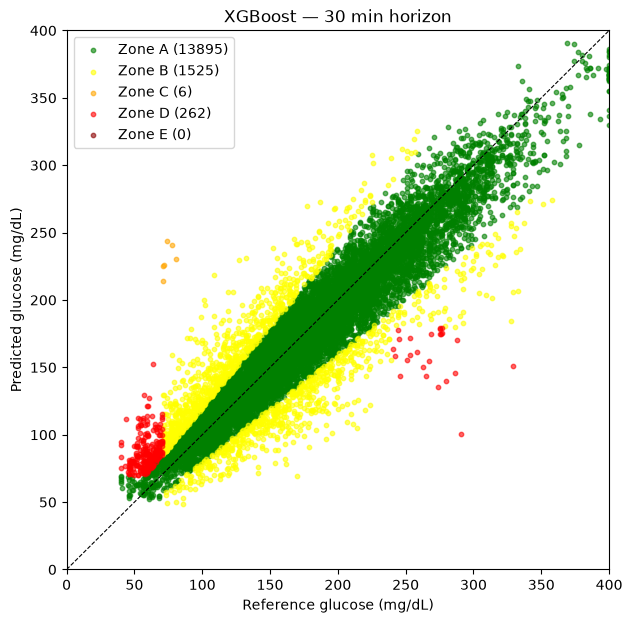

Zone breakdown (%):
  A: 88.57%
  B: 9.72%
  C: 0.04%
  D: 1.67%
  E: 0.00%

Clinically safe (A+B): 98.29%


In [68]:
zones1 = plot_clarke_grid(Y1_test, Y1_pred, title="XGBoost — 30 min horizon")

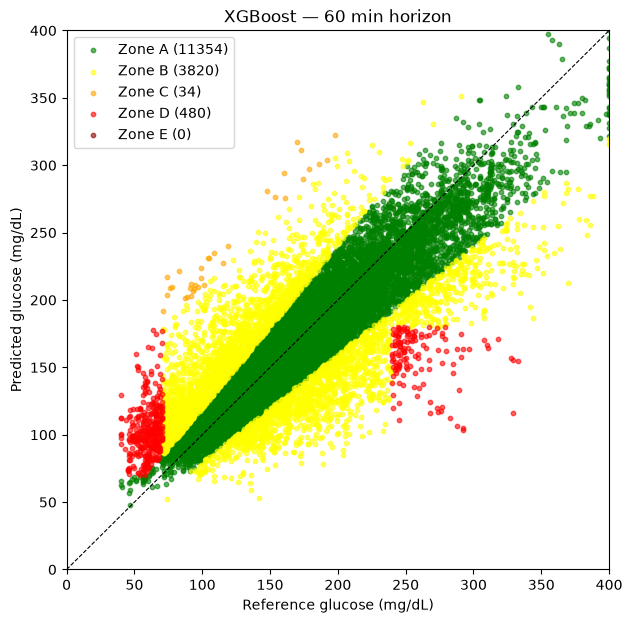

Zone breakdown (%):
  A: 72.37%
  B: 24.35%
  C: 0.22%
  D: 3.06%
  E: 0.00%

Clinically safe (A+B): 96.72%


In [69]:
zones2 = plot_clarke_grid(Y2_test, Y2_pred, title="XGBoost — 60 min horizon")

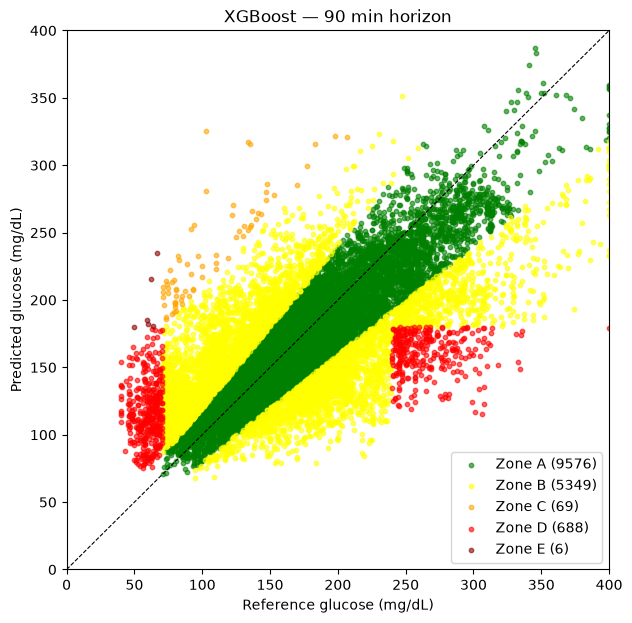

Zone breakdown (%):
  A: 61.04%
  B: 34.10%
  C: 0.44%
  D: 4.39%
  E: 0.04%

Clinically safe (A+B): 95.14%


In [70]:
zones3 = plot_clarke_grid(Y3_test, Y3_pred, title="XGBoost — 90 min horizon")

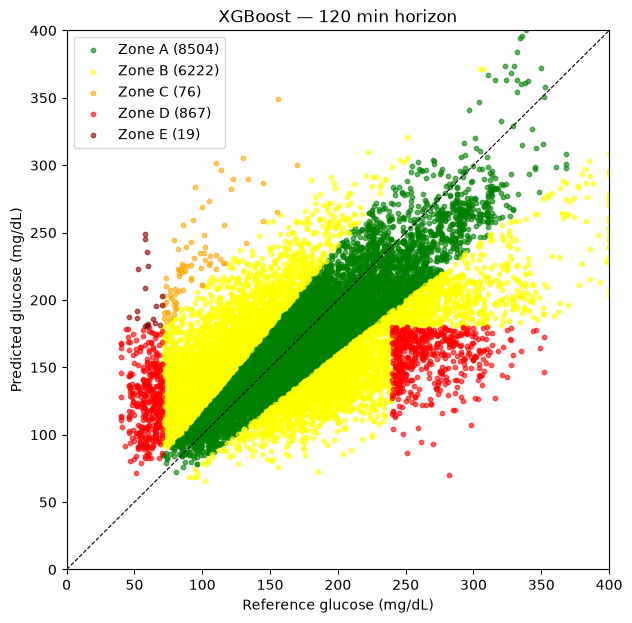

Zone breakdown (%):
  A: 54.21%
  B: 39.66%
  C: 0.48%
  D: 5.53%
  E: 0.12%

Clinically safe (A+B): 93.87%


In [71]:
zones4 = plot_clarke_grid(Y4_test, Y4_pred, title="XGBoost — 120 min horizon")